# 01 · Guesstimates: The Method and Easy Problems

A **guesstimate** (or Fermi problem) is a quick, structured estimate of a number that nobody can look up right now. "How many cups of coffee are sold in Paris every day?" You won't get the exact answer, but you can get the right **order of magnitude** (is it 10 thousand? 1 million? 100 million?) with clear reasoning.

**Why is this useful in data work?** All the time, before any data exists:

- Is this market big enough to build a product for?
- How much storage will this feature need next year?
- How long would an A/B test take with our traffic?
- Does this dashboard number look plausible, or is there a bug?

The last one is underrated: a quick estimate is the best way to catch a wrong number in a report.

**In this notebook**

1. A six-step method
2. Problem 1: water a person drinks in a lifetime
3. Problem 2: tennis balls in a school bus
4. Problem 3: cups of coffee sold in Paris per day

The second notebook has harder, data-science flavoured problems.

---
## The six-step method

| Step | What to do | Typical mistake |
|---|---|---|
| **1. Clarify** | Pin down exactly what is being counted, where, and over what time | Estimating something slightly different from the question |
| **2. Structure** | Break the number into a formula of smaller pieces (a tree) | Jumping straight to a guess |
| **3. Assume** | Give each piece a value **and a reason** | Hidden or unexplained numbers |
| **4. Calculate** | Multiply it out, keep round numbers | False precision ("1,734,219 cups") |
| **5. Sanity-check** | Compare with a second method or a known fact | Trusting the first answer |
| **6. Sensitivity** | Which assumption moves the answer most? | Treating every assumption as equally important |

Two ways to structure:

- **Top-down (demand side):** start from a population and narrow it down. Population → share who do X → how often.
- **Bottom-up (supply side):** start from the things that produce it. Number of shops → sales per shop.

Doing both and comparing them is the best sanity check there is.

Read more: [Fermi problem (Wikipedia)](https://en.wikipedia.org/wiki/Fermi_problem), with the original piano tuners example

> **Round numbers are fine.** Each assumption may be off by 20-50%, so writing 2,137,000 instead of 2 million adds nothing. What matters is that the **logic** is right.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"

I use the same small helper in every problem for the sensitivity step. It changes **one assumption at a time** to a low and a high value, keeps the others at their base value, and draws a **tornado chart**.

How to read a tornado chart: each bar shows how far the final answer moves when that one assumption goes from its low to its high value. The orange part is where the answer drops below the base estimate, the blue part where it rises above. The longest bar (at the top) is the assumption that matters most.

In [2]:
def sensitivity(estimate_function, assumptions, ranges):
    # change one assumption at a time, keep the others at their base value
    base_result = estimate_function(**assumptions)
    rows = []
    for name, (low, high) in ranges.items():
        result_low = estimate_function(**{**assumptions, name: low})
        result_high = estimate_function(**{**assumptions, name: high})
        rows.append({"assumption": name, "low value": low, "high value": high,
                     "result if low": result_low, "result if high": result_high})
    table = pd.DataFrame(rows)
    table["swing"] = (table["result if high"] - table["result if low"]).abs()
    return base_result, table.sort_values("swing")


def tornado_chart(base_result, table, title, unit, scale=1):
    base = base_result / scale
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(table) + 1.5))
    for i, (_, row) in enumerate(table.iterrows()):
        smallest = min(row["result if low"], row["result if high"]) / scale
        largest = max(row["result if low"], row["result if high"]) / scale
        ax.barh(i, base - smallest, left=smallest, color=ORANGE, height=0.5)
        ax.barh(i, largest - base, left=base, color=BLUE, height=0.5)
    ax.axvline(base, color="black", linewidth=1, label="base estimate")
    ax.set_yticks(range(len(table)))
    ax.set_yticklabels(table["assumption"])
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.margins(x=0.08)
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

---
## Problem 1 (easy): How much water does a person drink in a lifetime?

### 1. Clarify

- "Drink" = water drunk directly plus other drinks (tea, coffee, juice), not water inside food.
- One average adult in a country with normal access to drinking water.
- Answer in litres.

### 2. Structure

```
lifetime litres = litres per day × days per year × years of life
```

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| Litres per day | 2 | The common "8 glasses of 250 ml" advice. Children drink less, some adults more, so 2 is a fair lifetime average |
| Days per year | 365 | |
| Years of life | 80 | Close to life expectancy in many countries |

### 4. Calculate

By hand: 2 × 365 × 80 = 730 × 80 = **58,400 litres** ≈ **60,000 litres**

In [3]:
def lifetime_water(litres_per_day, years):
    return litres_per_day * 365 * years

base = {"litres_per_day": 2, "years": 80}
litres = lifetime_water(**base)
print(f"Lifetime water: {litres:,.0f} litres  =  {litres / 1000:.0f} cubic metres")

Lifetime water: 58,400 litres  =  58 cubic metres


### 5. Sanity check

58 m³ is hard to picture. A small backyard pool of 8 m × 4 m × 1.8 m holds about 58 m³. An Olympic pool holds about 2,500 m³, so a lifetime of drinking would fill about 1/40 of it. A small pool, not a lake: that feels right.

### 6. Sensitivity

In [4]:
ranges = {"litres_per_day": (1.2, 3.0), "years": (65, 90)}
base_result, table = sensitivity(lifetime_water, base, ranges)
table.round(1)

,assumption,low value,high value,result if low,result if high,swing
1,years,65.0,90.0,47450.0,65700.0,18250.0
0,litres_per_day,1.2,3.0,35040.0,87600.0,52560.0


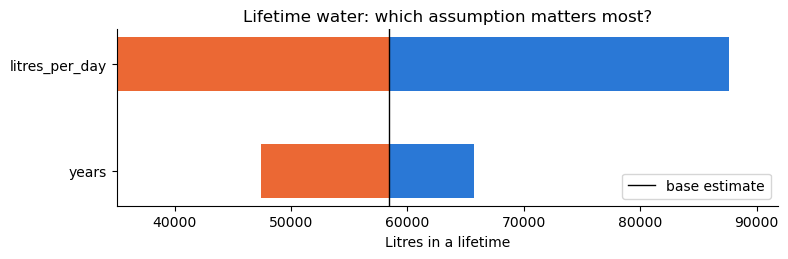

In [5]:
tornado_chart(base_result, table, "Lifetime water: which assumption matters most?", "Litres in a lifetime")

The daily amount matters most. Life expectancy changes the answer less, because its plausible range is narrower in relative terms. The answer stays between about 30,000 and 90,000 litres in any reasonable scenario: same order of magnitude.

---
## Problem 2 (easy): How many tennis balls fit in a school bus?

### 1. Clarify

- A standard full-size school bus (the long yellow American kind).
- Seats left inside (they take up space).
- Balls just poured in, not carefully stacked.

### 2. Structure

```
number of balls = (usable inside volume of the bus × packing efficiency) / volume of one ball
usable volume   = length × width × height − space taken by seats
```

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| Inside length | 10 m | A long bus is about 12 m, minus engine and driver area |
| Inside width | 2.3 m | Roads limit vehicles to about 2.5 m outside |
| Inside height | 1.9 m | An adult can stand up straight inside |
| Space taken by seats | 15% | Seats are mostly thin frames and cushions |
| Tennis ball diameter | 6.7 cm | Standard ball, about the size of a fist |
| Packing efficiency | 64% | Randomly poured spheres fill about 64% of a space (a well-known result). The rest is air between balls |

### 4. Calculate

By hand:

- Inside volume = 10 × 2.3 × 1.9 = 43.7 m³
- Usable = 43.7 × 0.85 = 37.1 m³
- Ball volume = 4/3 × π × r³ = 4/3 × 3.14 × 0.0335³ = 0.000157 m³ (about 157 cm³)
- Balls = 37.1 × 0.64 / 0.000157 = 23.7 / 0.000157 = **about 150,000**

In [6]:
def tennis_balls(length_m, width_m, height_m, seat_share, ball_diameter_cm, packing):
    inside_volume = length_m * width_m * height_m
    usable_volume = inside_volume * (1 - seat_share)
    radius_m = ball_diameter_cm / 100 / 2
    ball_volume = 4 / 3 * np.pi * radius_m ** 3
    return usable_volume * packing / ball_volume

base = {"length_m": 10, "width_m": 2.3, "height_m": 1.9, "seat_share": 0.15,
        "ball_diameter_cm": 6.7, "packing": 0.64}
balls = tennis_balls(**base)
print(f"Tennis balls in a school bus: {balls:,.0f}")

Tennis balls in a school bus: 150,958


### 5. Sanity check (a second method)

Think of a ball as taking up a small cube of 6.7 cm (its diameter) on each side, which is like stacking them in neat rows. A cube of 6.7 cm has a volume of 301 cm³ = 0.000301 m³. Then: 37.1 m³ / 0.000301 m³ ≈ 123,000. Random pouring packs a bit better than neat square stacking, so 150,000 vs 123,000 makes sense. Both point to **"between 100,000 and 200,000"**.

> A confession: in my first draft of this problem I wrote the ball volume as 0.0000157 m³ (one zero too many) and got 1.5 million. The code result didn't match, and that's how I found the mistake. Units and powers of ten are where most guesstimate errors hide, so always check them twice.

In [7]:
cube_method = 37.1 / (0.067 ** 3)
print(f"Cube method: {cube_method:,.0f} balls")

Cube method: 123,353 balls


### 6. Sensitivity

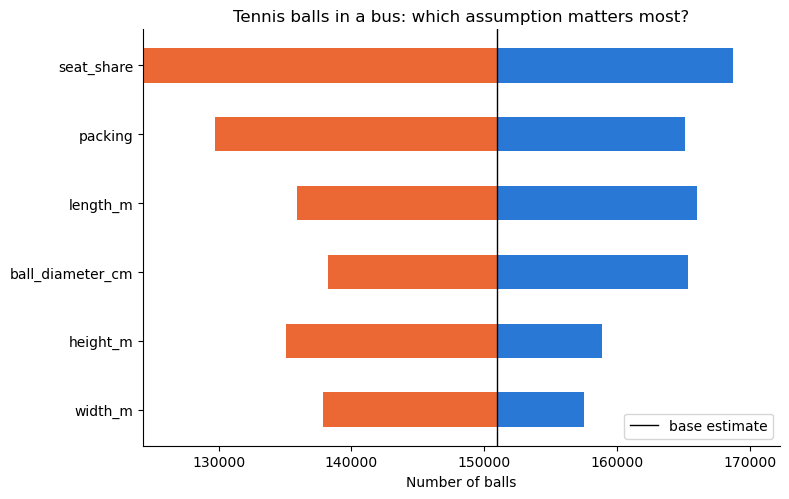

In [8]:
ranges = {
    "length_m": (9, 11),
    "width_m": (2.1, 2.4),
    "height_m": (1.7, 2.0),
    "seat_share": (0.05, 0.30),
    "ball_diameter_cm": (6.5, 6.9),
    "packing": (0.55, 0.70),
}
base_result, table = sensitivity(tennis_balls, base, ranges)
tornado_chart(base_result, table, "Tennis balls in a bus: which assumption matters most?", "Number of balls")

Seats and packing matter most. Notice the ball diameter: a change of only ±2 mm moves the answer quite a lot, because volume grows with the **cube** of the size. Small errors in a "cubed" quantity get amplified, so it's worth getting those right.

---
## Problem 3 (easy-medium): How many cups of coffee are sold in Paris per day?

### 1. Clarify

- "Sold": bought in cafés, bakeries, kiosks, offices, vending machines. Coffee made at home doesn't count.
- "Paris": the city itself (about 2.1 million residents), on a normal weekday.

### 2. Structure (top-down, demand side)

```
cups sold = (residents × adult share × coffee drinker share × cups per drinker per day × share bought outside)
          + (commuters and tourists × cups each)
```

### 3. Assumptions

| Assumption | Value | Reason |
|---|---|---|
| Residents | 2.1 million | Population of the city of Paris |
| Adults (15+) | 85% | Children rarely drink coffee |
| Coffee drinkers among adults | 70% | France is a coffee-drinking country. Some people only drink tea or nothing |
| Cups per drinker per day | 2.5 | Breakfast, after lunch, maybe one more |
| Share of cups bought outside | 30% | Most coffee is made at home or in the office kitchen |
| Extra people per day (commuters from the suburbs + tourists) | 1.5 million | Paris pulls in a lot of daily workers and visitors |
| Bought cups per extra person | 0.8 | They're away from home all day, so they buy more often |

In [9]:
def coffee_cups(residents, adult_share, drinker_share, cups_per_drinker, share_bought, visitors, cups_per_visitor):
    residents_cups = residents * adult_share * drinker_share * cups_per_drinker * share_bought
    visitor_cups = visitors * cups_per_visitor
    return residents_cups + visitor_cups

base = {"residents": 2.1e6, "adult_share": 0.85, "drinker_share": 0.70, "cups_per_drinker": 2.5,
        "share_bought": 0.30, "visitors": 1.5e6, "cups_per_visitor": 0.8}

cups_demand = coffee_cups(**base)
print(f"Residents: {2.1e6 * 0.85 * 0.70 * 2.5 * 0.30:,.0f} cups")
print(f"Visitors : {1.5e6 * 0.8:,.0f} cups")
print(f"Total (demand side): {cups_demand:,.0f} cups per day")

Residents: 937,125 cups
Visitors : 1,200,000 cups
Total (demand side): 2,137,125 cups per day


By hand: residents 2.1M × 0.85 × 0.7 × 2.5 × 0.3 ≈ 0.94M. Visitors 1.5M × 0.8 = 1.2M. Total ≈ **2.1 million cups per day**.

### 5. Sanity check (bottom-up, supply side)

Count the places that sell coffee instead:

| Assumption | Value | Reason |
|---|---|---|
| Cafés, bistros, bakeries, coffee shops, kiosks | 15,000 | Paris has a café on almost every street corner. Roughly one per 140 residents |
| Average cups sold per place per day | 120 | A busy café sells several hundred, a small bakery maybe 30 |

In [10]:
places = 15_000
cups_per_place = 120
cups_supply = places * cups_per_place
print(f"Supply side: {cups_supply:,.0f} cups per day")
print(f"Ratio demand / supply: {cups_demand / cups_supply:.2f}")

Supply side: 1,800,000 cups per day
Ratio demand / supply: 1.19


Demand side ≈ 2.1 million, supply side ≈ 1.8 million. Two completely different ways of thinking land within about 20% of each other, so I'm fairly confident the answer is **around 2 million cups per day**, and very likely between 1 and 4 million.

If the two methods had disagreed by 10×, that would be a signal that one of the assumptions is badly wrong, and it's worth finding which one.

### 6. Sensitivity

In [11]:
ranges = {
    "drinker_share": (0.55, 0.80),
    "cups_per_drinker": (1.5, 3.5),
    "share_bought": (0.15, 0.45),
    "visitors": (0.8e6, 2.0e6),
    "cups_per_visitor": (0.4, 1.2),
}
base_result, table = sensitivity(coffee_cups, base, ranges)
display_table = table.copy()
display_table[["result if low", "result if high", "swing"]] = (display_table[["result if low", "result if high", "swing"]] / 1e6).round(2)
display_table

,assumption,low value,high value,result if low,result if high,swing
0,drinker_share,0.55,0.80,1.94,2.27,0.33
1,cups_per_drinker,1.50,3.50,1.76,2.51,0.75
2,share_bought,0.15,0.45,1.67,2.61,0.94
3,visitors,800000.00,2000000.00,1.58,2.54,0.96
4,cups_per_visitor,0.40,1.20,1.54,2.74,1.20


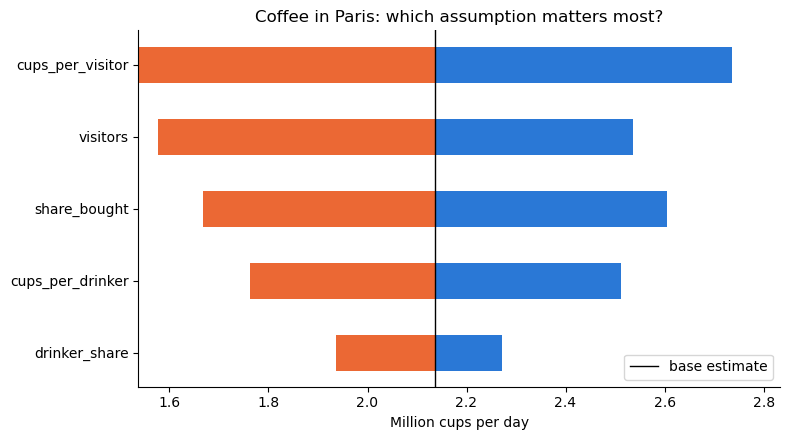

In [12]:
tornado_chart(base_result, table, "Coffee in Paris: which assumption matters most?", "Million cups per day", scale=1e6)

The visitor assumptions matter as much as the residents' habits, so if I had to research **one** number to improve this estimate, it would be how many commuters and tourists come into Paris on a typical day and how often they buy coffee. That's the main value of a sensitivity check: it tells you where to spend your effort.

---
## Summary

| Problem | Estimate | Key driver |
|---|---|---|
| Water in a lifetime | about 60,000 litres | Litres per day |
| Tennis balls in a bus | about 150,000 | Seat space and packing (and ball size, cubed) |
| Coffee in Paris | about 2 million cups / day | Visitors and share bought outside |

What these have in common:

1. A clear definition before any number.
2. A formula of small pieces, each with a reason.
3. A second method to cross-check.
4. A sensitivity check to find the assumption that matters.

## What's next

In **02 · Guesstimates for Data Science Problems** the same method is applied to problems closer to real data work: smartphone sales, daily active users, search traffic, storage needs, app revenue, and how long an A/B test needs to run.

## References and further reading

- [Fermi problem, Wikipedia](https://en.wikipedia.org/wiki/Fermi_problem)
- [Random close pack, Wikipedia](https://en.wikipedia.org/wiki/Random_close_pack) (the 64% packing figure used for the tennis balls)
- [Sensitivity analysis, Wikipedia](https://en.wikipedia.org/wiki/Sensitivity_analysis) · [Tornado diagram, Wikipedia](https://en.wikipedia.org/wiki/Tornado_diagram)